## Imports

In [1]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.metrics import accuracy_score
import perceval as pcvl
from sklearn.neighbors import NearestCentroid
from src.classifier import QuantumNearestCentroid, MLQuantumNearestCentroid
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import MinMaxScaler
from src.utils import create_circuit


## Encoding the data

This article uses the circuit as a way to do a inner product between two vectors x and y, to then compute a quantum distance between x and y. To do so, the article presents a new type of encoding of the data. Here is how this encoding is defined:

 $ r_{d/2+j-1} = \sqrt{x_{2j}^2 + x_{2j-1}^2}$
   for the first d/2 − 1 values, namely the values of (r1, r2, …, rd/2−1), and for
j in [1, d/2], we define

$ r_{j} = \sqrt{r_{2j}^2 + r_{2j+1}^2}$

From the values r and x we can now calculate the theta angles set in the quantum circuit

$θ_{d/2+j-1} = \arccos{\frac{x_{2j-1}}{r_{d/2+j-1}}}  $ if $x_{2j}$ is positive

$θ_{d/2+j-1} = 2\pi - \arccos{\frac{x_{2j-1}}{r_{d/2+j-1}}}  $ if $x_{2j}$ is negative


The encoding for y is similar to x except the following step :

$θ_{d/2+j-1} = \arccos{\frac{y_{2j-1}}{r_{d/2+j-1}}}  $ if $y_{2j}$ is negative

$θ_{d/2+j-1} = 2\pi - \arccos{\frac{y_{2j-1}}{r_{d/2+j-1}}}  $ if $y_{2j}$ is positive

Below you can see the circuit used for an input of size 4 (Iris Dataset for instance)


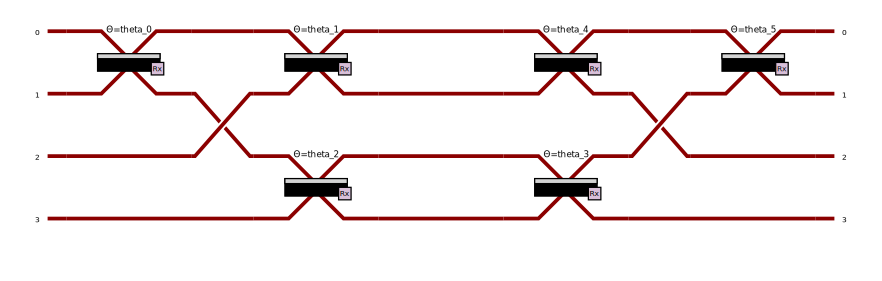

In [2]:
circuit = create_circuit(4)
pcvl.pdisplay(circuit)

## Quantum distance
The quantum circuit is initiated with the input state with one photon on the first mode and zero on the other modes.
The algorithm then computes the result of the quantum inner product:

$$inner = \sqrt{\frac{\text{number of initial states measured}}{\text{total states}}}$$

And the quantum distance between x and y:

$$ distance (x, y) = ||x|| + ||y|| - 2 \times inner \times ||x|| \times ||y|| $$

The quantum nearest centroid is then defined as the NearestCentroid with the get_metric method modified to have the quantum distance described above as a new metric. The merlin version computes this quantum distance using Merlin whereas the paper version used the cirq framework.

### Experiment on Iris dataset

In [3]:
def iris_experiment(model):
    iris = datasets.load_iris()
    X = iris.data
    y = y_true = iris.target

    # train model
    model.fit(X, y)

    # test model
    y_pred = model.predict(X)
    score = accuracy_score(y_true, y_pred)
    error = 100 * (1. - score)

    return error

def iris_plot(c_error, q_errors):
    labels = ['100', '500', '1000', '5000']

    x = np.arange(len(labels))
    c_error = [c_error] * len(labels)
    width = 0.35

    fig, ax = plt.subplots()
    ax.bar(x - width/2, q_errors[0], width, label='quantum')
    ax.bar(x + width/2, c_error, width, label='classical')

    ax.set_ylabel('Classification error %')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend(loc='lower right')

    fig.tight_layout()

    plt.show()

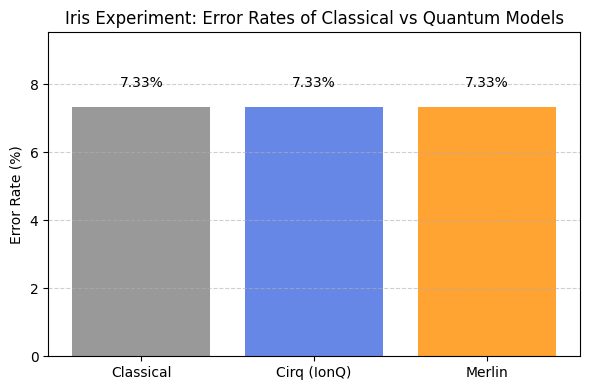

In [4]:

c_model = NearestCentroid()
q_model_cirq = QuantumNearestCentroid(error_rate=0, repetitions=5000)
q_model_ml = MLQuantumNearestCentroid(n=4)
c_error = iris_experiment(c_model)
q_errors = []


models = ["Classical", "Cirq (IonQ)", "Merlin"]
errors = [c_error, iris_experiment(q_model_cirq), iris_experiment(q_model_ml)]

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(models, errors, color=["gray", "royalblue", "darkorange"], alpha=0.8)

# Annotate bars with values
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.2f}%",
            ha='center', va='bottom', fontsize=10)

# Style
ax.set_ylim(0, max(errors) * 1.3)
ax.set_ylabel("Error Rate (%)")
ax.set_title("Iris Experiment: Error Rates of Classical vs Quantum Models")
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Experiment on MNIST

MNIST is a dataset of images representing the 10 digits 0-9. The images are of size (28x28) but to calculate the quantum distance we put the images through a PCA (Principal Components Analysis) and select the first 8 components.


In [5]:

# 1. Load MNIST dataset
# ----------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 -> 784
])

mnist = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
X = mnist.data.numpy().reshape(len(mnist), -1)
y = mnist.targets.numpy()

# ----------------------
# 2. Classification experiments with subsets + PCA + error bars
# ----------------------
def run_subset_experiment(classes, n_samples, n_repeats=10):
    accs = []
    ml_accs = []
    c_accs = []
    for _ in range(n_repeats):
        mask = np.isin(y, classes)
        X_sub, y_sub = X[mask], y[mask]

        # balance classes & subsample
        X_sel, _, y_sel, _ = train_test_split(X_sub, y_sub, train_size=2*n_samples, stratify=y_sub)

        # train/test split
        X_train, X_test, y_train, y_test = train_test_split(X_sel, y_sel, test_size=0.5, stratify=y_sel)

        # Apply PCA (8 components)
        pca = PCA(n_components=8)
        X_train_pca = pca.fit_transform(X_train)
        X_test_pca = pca.transform(X_test)
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train_pca)
        X_test_scaled = scaler.transform(X_test_pca)
        # Nearest Centroid classifier
        c = NearestCentroid()
        clf = QuantumNearestCentroid()
        clf_ml = MLQuantumNearestCentroid(n=8)
        c.fit(X_train_pca, y_train)
        clf.fit(X_train_scaled, y_train)
        clf_ml.fit(X_train_scaled, y_train)
        c_acc = c.score(X_test_pca, y_test)
        acc = clf.score(X_test_scaled, y_test)
        ml_acc = clf_ml.score(X_test_scaled, y_test)
        c_accs.append(c_acc)
        accs.append(acc)
        ml_accs.append(ml_acc)
    return np.mean(accs), np.std(accs), np.mean(ml_accs), np.std(ml_accs), np.mean(c_accs), np.std(c_accs)

experiments = [
    ([0, 1], 40),
    ([2, 7], 40),
]



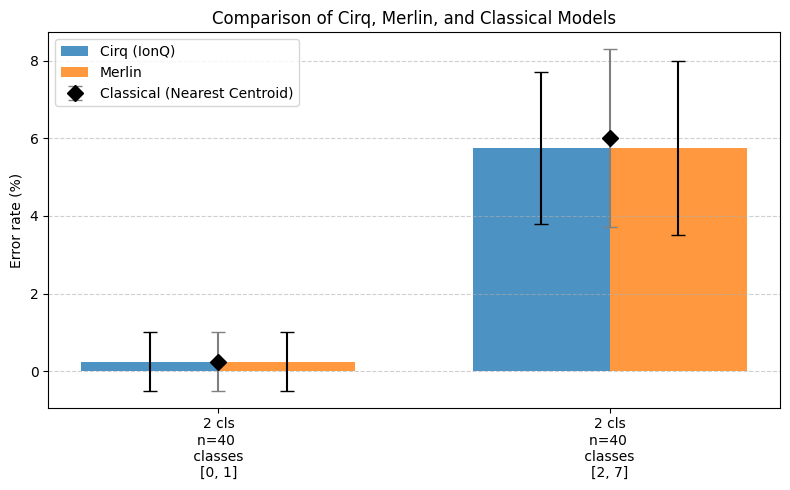

In [6]:
cirq_means, cirq_stds = [], []
merlin_means, merlin_stds = [], []
class_means, class_stds = [], []
labels = []

for classes, n in experiments:
    mean_acc, std_acc, ml_mean, ml_std, c_mean, c_std = run_subset_experiment(classes, n)
    cirq_means.append((1-mean_acc) * 100)
    cirq_stds.append(std_acc * 100)
    merlin_means.append((1-ml_mean) * 100)
    merlin_stds.append(ml_std * 100)
    class_means.append((1-c_mean) * 100)
    class_stds.append(c_std * 100)
    labels.append(f"{len(classes)} cls\nn={n} \n classes \n{classes}")

# Convert to numpy arrays
x = np.arange(len(experiments))
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(8, 5))

# Bars
bars1 = ax.bar(x - width/2, cirq_means, width, yerr=cirq_stds, label="Cirq (IonQ)", alpha=0.8, capsize=5)
bars2 = ax.bar(x + width/2, merlin_means, width, yerr=merlin_stds, label="Merlin", alpha=0.8, capsize=5)

# Classical points (diamonds)
ax.errorbar(
    x, class_means, yerr=class_stds,
    fmt='D', markersize=8, color='black', ecolor='gray',
    elinewidth=1.5, capsize=5, label="Classical (Nearest Centroid)"
)

# Aesthetics
ax.set_ylabel("Error rate (%)")
ax.set_title("Comparison of Cirq, Merlin, and Classical Models")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()